# Load data

In [1]:
!pip install rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 26.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [rasterio]4/5 [rasterio]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import geopandas as gpd
import pandas as pd

In [3]:
subbasin_gdf = gpd.read_file('../data/raw/hydrography/gsl_catchment.shp')
gage_df = pd.read_csv('../data/raw/hydrography/gsl_nwm_gage.csv')
well_gdf = gpd.read_file('../data/raw/hydrography/well_shp.shp')
stream_gdf = gpd.read_file('../data/raw/hydrography/gslb_stream.shp')
lake_gdf = gpd.read_file('../data/raw/hydrography/lake.shp')

# find downstream gage

In [4]:
from geopandas import GeoDataFrame
from shapely.geometry import Point

# Convert gage dataframe to GeoDataFrame (to match with subbasin_gdf)
# Create point geometries from longitude/latitude coordinates
gage_gdf = gpd.GeoDataFrame(
    gage_df,
    geometry=gpd.points_from_xy(gage_df['longitude'], gage_df['latitude']),
    crs=subbasin_gdf.crs
)

# Spatial join to find which subbasin each gage falls within
# Only keep gages that are within a subbasin (inner join)
matched_gages = gpd.sjoin(
    gage_gdf[['id', 'name', 'geometry']],
    subbasin_gdf[['linkno', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'linkno': 'catchment_id'})

# Keep only relevant columns
matched_gages = matched_gages[['id', 'name', 'geometry', 'catchment_id']]



In [5]:
# Create a directed graph representing the river network
import networkx as nx
G = nx.DiGraph()

# Add edges to graph based on stream connectivity
# DSLINKNO represents downstream link number
for _, row in stream_gdf.iterrows():
    if pd.notna(row['DSLINKNO']) and row['DSLINKNO'] > 0:
        G.add_edge(int(row['LINKNO']), int(row['DSLINKNO']))

# Create dictionary mapping gage IDs to their catchment IDs
gage_links = dict(zip(matched_gages['id'], matched_gages['catchment_id']))
terminal_ids = []

# Find terminal gages (those that don't flow to any other gage)
for g1_id, g1_link in gage_links.items():
    is_terminal = True
    for g2_id, g2_link in gage_links.items():
        if g1_id != g2_id:
            try:
                # If there's a path from g1 to g2, then g1 is not terminal
                if nx.has_path(G, g1_link, g2_link):
                    is_terminal = False
                    break
            except:
                continue
    if is_terminal:
        terminal_ids.append(g1_id)

In [6]:
# Manual adjustments to terminal gages list based on domain knowledge
gages_to_remove = [10171000, 10167000]
gages_to_add = [10163000, 10153100, 10152000]

In [7]:
# Remove specified gages
terminal_ids = [gage_id for gage_id in terminal_ids if gage_id not in gages_to_remove]

# Add new gages if they exist in matched_gages
for gage_id in gages_to_add:
    if gage_id in matched_gages['id'].values and gage_id not in terminal_ids:
        terminal_ids.append(gage_id)

# Create dataframe of terminal gages
terminal_gages = matched_gages[matched_gages['id'].isin(terminal_ids)].copy()

# Find all upstream catchments for each terminal gage
records = []
for _, gage in terminal_gages.iterrows():
    upstream_ids = set()
    # Check each node in the graph
    for node in G.nodes:
        # If there's a path from node to terminal gage's catchment,
        # then this node is upstream
        if nx.has_path(G, node, gage['catchment_id']):
            upstream_ids.add(node)
    # Include the terminal gage's own catchment
    upstream_ids.add(gage['catchment_id'])

    # Create records for each upstream catchment
    for up_id in upstream_ids:
        records.append({
            'Gage_ID': gage['id'],
            'Gage_Name': gage['name'],
            'Terminal_Catchment_ID': gage['catchment_id'],
            'Upstream_Catchment_ID': up_id
        })

# Create and save the final dataframe
df_upstream = pd.DataFrame(records)
df_upstream.to_csv("../data/processed/terminal_gage_upstream_catchments.csv", index=False)

In [8]:
print(f'Number of unique gages in df_upstream: {df_upstream["Gage_ID"].nunique()}')
print('\nTerminal gage names:')
for _, row in df_upstream[['Gage_ID', 'Gage_Name']].drop_duplicates().iterrows():
    print(f'{row["Gage_ID"]}: {row["Gage_Name"]}')


Number of unique gages in df_upstream: 12

Terminal gage names:
10126000: BEAR RIVER NEAR CORINNE - UT
10141000: WEBER RIVER NEAR PLAIN CITY - UT
10142000: FARMINGTON CR ABV DIV NR FARMINGTON - UTAH
10143500: CENTERVILLE CREEK ABV. DIV NEAR CENTERVILLE - UT
10152000: SPANISH FORK NEAR LAKE SHORE - UTAH
10153100: HOBBLE CREEK AT 1650 WEST AT SPRINGVILLE - UTAH
10163000: PROVO RIVER AT PROVO - UT
10168000: LITTLE COTTONWOOD CREEK @ JORDAN RIVER NR SLC
10168500: BIG COTTONWOOD CR NR SALT LAKE CITY UTAH
10172700: VERNON CREEK NEAR VERNON - UT
10172860: WARM CREEK NEAR GANDY - UT
10172952: DUNN CREEK NEAR PARK VALLEY - UT


# Plot

In [9]:
import matplotlib.pyplot as plt
plt.style.use('default')  # Reset any style settings

In [11]:
!pip install plotly
!pip install plotly-express
!pip install plotly-graph-objects
!pip install plotly-subplots
!pip install plotly
!pip install plotly-express
!pip install plotly-graph-objects

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 34.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 61.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [plotly-express]m [statsmodels]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement plotly-graph-objects (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for plotly-graph-objects
ERROR: Could not find a version that satisfies the requirement plotly-subplots (from versions: none)

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run:

In [12]:
# ... existing code ...
import numpy as np
import pandas as pd
import geopandas as gpd
# If you previously had "import plotly as plt", remove it and use explicit aliases instead:
import matplotlib.pyplot as plt
import plotly.express as px         # if you use Plotly Express
import plotly.graph_objects as go    # if you use Graph Objects
from plotly.subplots import make_subplots  # if you need Plotly subplots
# ... existing code ...
import plotly.express as px

=== Creating Enhanced Watershed Visualization ===
  Streams total: 6717, order >= 4: 1765
  Wells total: 8752, within subbasin: 8740


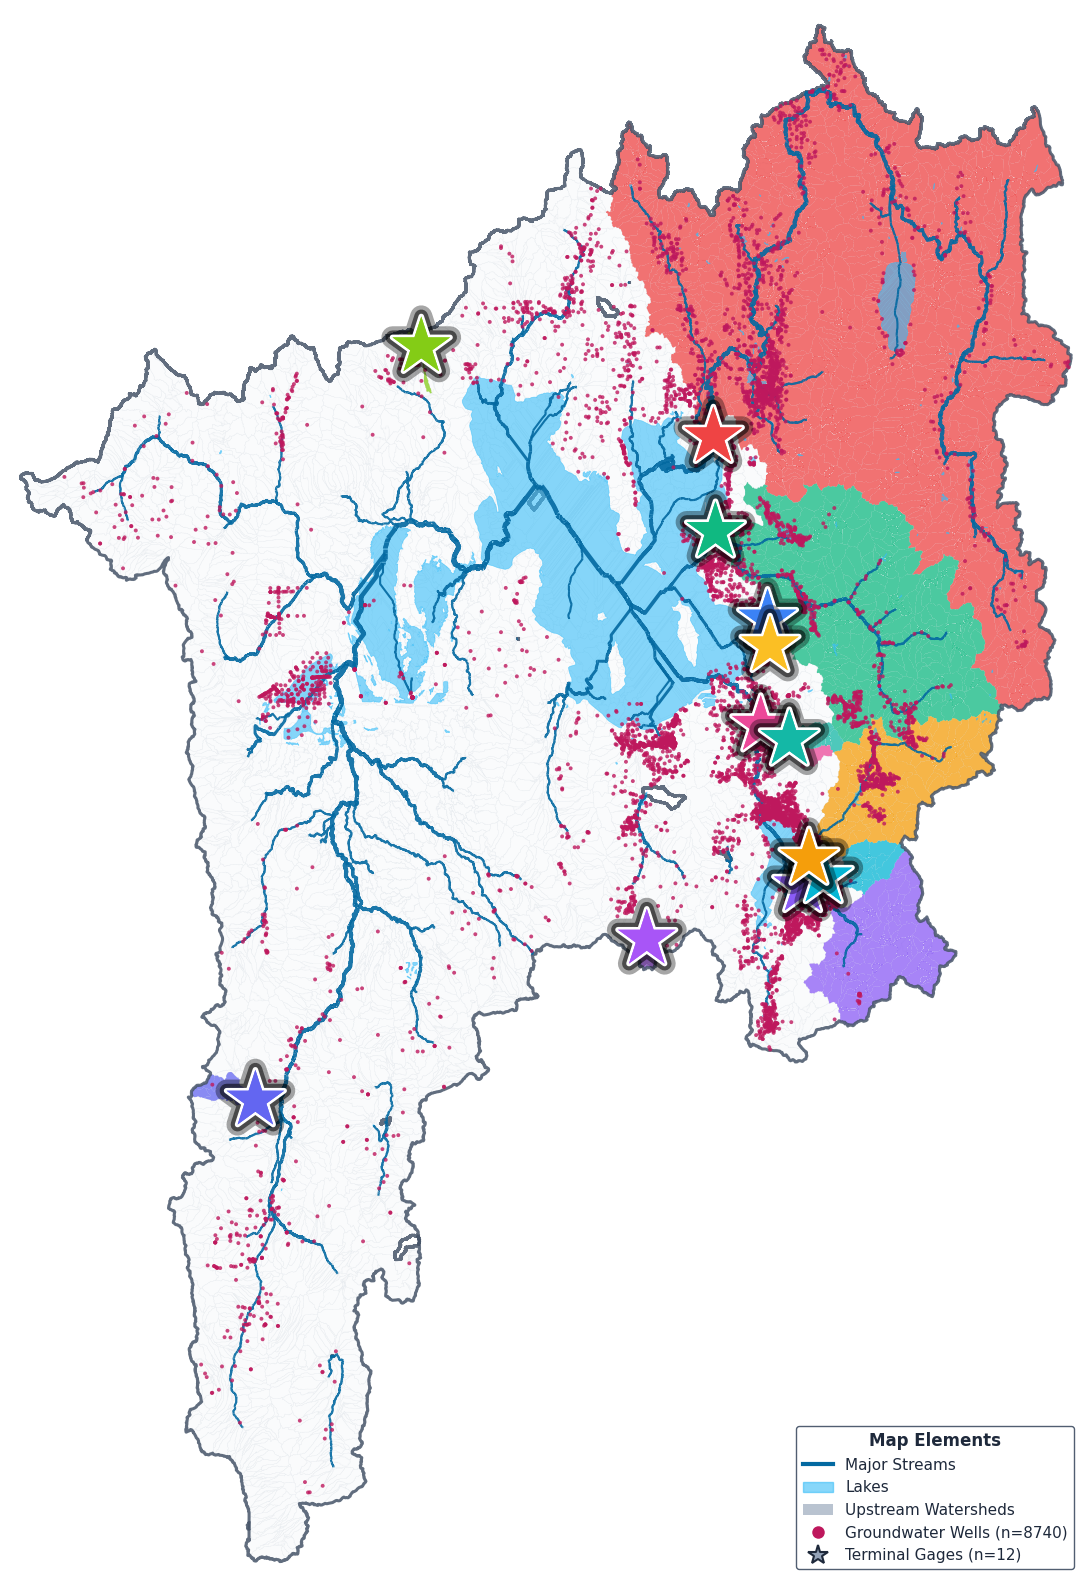

Saved: ../reports/figures/enhanced_terminal_gages_watersheds.png
Wells plotted: 8740 of 8752 (within subbasin)
Streams plotted: 1765 of 6717 (order >= 4)


In [33]:
from gwbase.visualization import create_enhanced_watershed_visualization

create_enhanced_watershed_visualization()


# find wells

In [14]:
# Perform spatial join between well_gdf and subbasin_gdf
# Use 'within' predicate to determine which catchment each well belongs to
wells_in_catchments = gpd.sjoin(
    well_gdf,
    subbasin_gdf[['linkno', 'geometry']],
    how='inner',
    predicate='within'
).rename(columns={'linkno': 'catchment_id'})

# Add gage information by matching catchment_id to upstream_catchment_id
wells_in_catchments = wells_in_catchments.merge(
    df_upstream[['Gage_ID', 'Gage_Name', 'Upstream_Catchment_ID']],
    left_on='catchment_id',
    right_on='Upstream_Catchment_ID',
    how='left'
)

# Convert column names to lowercase
wells_in_catchments.columns = wells_in_catchments.columns.str.lower()

# Drop unnecessary columns
wells_in_catchments = wells_in_catchments.drop(
    ['aquiferid', 'aquifer_na', 'state', 'index_right', 'upstream_catchment_id'], axis=1)

# Only keep rows where gage_id is not null
wells_in_catchments = wells_in_catchments.dropna(subset=['gage_id'])

# Save summary file
wells_in_catchments.to_csv("../data/processed/wells_with_catchment_info.csv", index=False)

# Group by catchment and count number of wells in each catchment
wells_count = wells_in_catchments.groupby(['catchment_id', 'gage_id', 'gage_name']).size().reset_index(
    name='well_count')
print("\nNumber of wells in each catchment:")
print(wells_count)

# Get detailed well information for each catchment
print("\nDetailed well information for each catchment:")
for catchment_id in wells_in_catchments['catchment_id'].unique():
    wells = wells_in_catchments[wells_in_catchments['catchment_id'] == catchment_id]
    gage_info = wells[['gage_id', 'gage_name']].iloc[0]
    print(
        f"\nWells in Catchment {catchment_id} (Gage {gage_info['gage_id']} - {gage_info['gage_name']}, {len(wells)} wells):")
    print(wells)



Number of wells in each catchment:
     catchment_id     gage_id                            gage_name  well_count
0     710119132.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           1
1     710129059.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           2
2     710148899.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           3
3     710154841.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           8
4     710160811.0  10126000.0         BEAR RIVER NEAR CORINNE - UT           2
..            ...         ...                                  ...         ...
589   710972343.0  10141000.0     WEBER RIVER NEAR PLAIN CITY - UT           1
590   710988246.0  10152000.0  SPANISH FORK NEAR LAKE SHORE - UTAH          20
591   711004110.0  10163000.0            PROVO RIVER AT PROVO - UT          25
592   711023947.0  10163000.0            PROVO RIVER AT PROVO - UT          11
593   711025943.0  10152000.0  SPANISH FORK NEAR LAKE SHORE - UTAH          53

[594 rows x 4 c

In [15]:
# Group wells by gage and count
gage_well_counts = wells_in_catchments.groupby(['gage_id', 'gage_name']).size().reset_index(name='well_count')

# Sort by well count descending
gage_well_counts = gage_well_counts.sort_values('well_count', ascending=False)

print("Wells per gage:")
print(gage_well_counts)


Wells per gage:
      gage_id                                         gage_name  well_count
0  10126000.0                      BEAR RIVER NEAR CORINNE - UT        1461
1  10141000.0                  WEBER RIVER NEAR PLAIN CITY - UT         732
6  10163000.0                         PROVO RIVER AT PROVO - UT         471
4  10152000.0               SPANISH FORK NEAR LAKE SHORE - UTAH          92
7  10168000.0     LITTLE COTTONWOOD CREEK @ JORDAN RIVER NR SLC          73
3  10143500.0  CENTERVILLE CREEK ABV. DIV NEAR CENTERVILLE - UT          20
5  10153100.0   HOBBLE CREEK AT 1650 WEST AT SPRINGVILLE - UTAH          16
2  10142000.0        FARMINGTON CR ABV DIV NR FARMINGTON - UTAH          13
8  10172860.0                        WARM CREEK NEAR GANDY - UT           1
9  10172952.0                  DUNN CREEK NEAR PARK VALLEY - UT           1


# plot each gage and upstream catchments

In [18]:
from gwbase.visualization import create_enhanced_gage_maps

create_enhanced_gage_maps()


=== Creating Enhanced Terminal Gage Maps ===
✅ Data loaded successfully
🎯 Will create maps for 12 terminal gages


Creating maps:   0%|          | 0/12 [00:30<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
from gwbase.visualization import create_upstream_catchment_schematic

create_upstream_catchment_schematic()
